# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [54]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


torch.manual_seed(1234)

In [55]:

!pwd

/content


In [56]:

#!/bin/bash
!curl -L -o /content/housesalesprediction.zip https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  4109k      0 --:--:-- --:--:-- --:--:-- 4109k


In [57]:
!unzip /content/housesalesprediction.zip

Archive:  /content/housesalesprediction.zip
replace kc_house_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: kc_house_data.csv       


In [58]:
df = pd.read_csv('kc_house_data.csv')

In [59]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Leitura dos dados

In [60]:
# Load the dataset
X = df[['sqft_living']].values #Area da casa
y = df[['price']].values #Preço

In [61]:
y

array([[221900.],
       [538000.],
       [180000.],
       ...,
       [402101.],
       [400000.],
       [325000.]])

### Normalização dos dados

In [62]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [63]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 1])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 1])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [64]:
model = torch.nn.Linear(1, 1)

### Verificando a inicialização dos parâmetros

In [65]:
model.weight.data

tensor([[-0.9420]])

### Testando o predict da rede

In [66]:
model(torch.ones(5,1))

tensor([[-1.1382],
        [-1.1382],
        [-1.1382],
        [-1.1382],
        [-1.1382]], grad_fn=<AddmmBackward0>)

In [67]:
model(X_train_tensor[:3])

tensor([[-0.8117],
        [-0.4630],
        [-0.3091]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [68]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.3)
num_epochs = 120

### Laço de treinamento

In [69]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [70]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [71]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # verbose
    if (epoch + 1) % 2 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[2/120], Train Loss: 0.938550, Val Loss: 0.638228
Epoch[4/120], Train Loss: 0.500282, Val Loss: 0.556032
Epoch[6/120], Train Loss: 0.487937, Val Loss: 0.553065
Epoch[8/120], Train Loss: 0.487589, Val Loss: 0.552871
Epoch[10/120], Train Loss: 0.487579, Val Loss: 0.552847
Epoch[12/120], Train Loss: 0.487579, Val Loss: 0.552843
Epoch[14/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[16/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[18/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[20/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[22/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[24/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[26/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[28/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[30/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[32/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[34/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[36/120], Train Loss: 0.487578, Val Loss: 0.552

## Avaliação

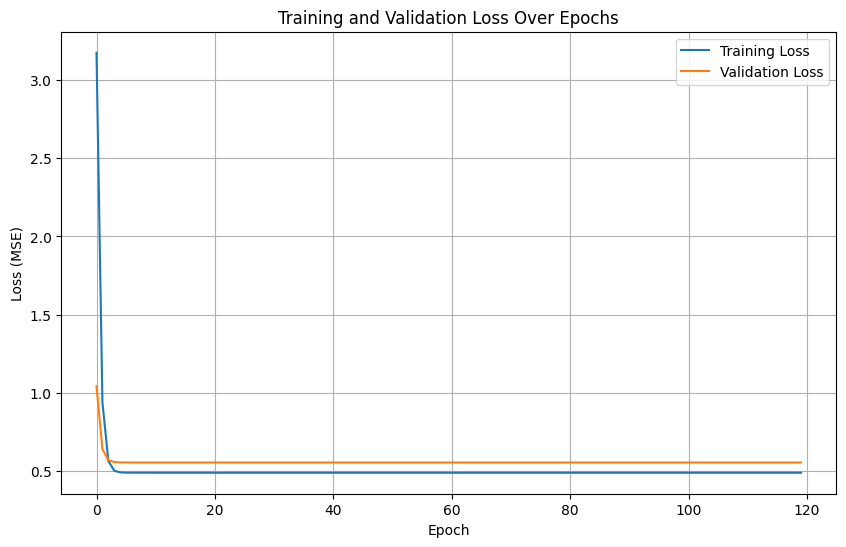

In [72]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()